<a href="https://colab.research.google.com/github/Livianita/nhl-api./blob/main/Copia_de_Laboratorio_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Actividad — De la web a una API

Bajas estadísticas de equipos de la NHL, entrenas un modelo que predice si una
temporada fue ganadora, y lo dejas respondiendo dentro de un contenedor.

Al final hay una parte **opcional**: publicarlo en Internet con una URL que
pueda abrir cualquiera.

**El código de Python ya está escrito.** Tu trabajo es ejecutarlo, entender
qué pasa en cada paso y responder las preguntas. Lo que sí tienes que hacer
funcionar por tu cuenta es la **API** y el **contenedor**.

**Entregas:** este notebook ejecutado + una captura de la API respondiendo.

---
## Antes de empezar: ¿qué vamos a predecir?

Cada fila de los datos son **las estadísticas de un equipo de la NHL en una
temporada**. El scraper construye estas nueve columnas:

```python
COLS = ["equipo", "anio", "victorias", "derrotas", "ot",
        "win_pct", "gf", "ga", "dif"]
```

Las cuatro que importan hoy:

| columna | qué es |
|---|---|
| `gf` | *goals for* — goles que **anotó** el equipo |
| `ga` | *goals against* — goles que **recibió** |
| `dif` | la diferencia: `gf - ga` |
| `win_pct` | la proporción de partidos ganados |

Así se ve, en concreto:

```
equipo     gf    ga    dif    win_pct
Boston     300   220     80      0.67
Detroit    210   280    -70      0.38
```

Boston anotó 80 goles más de los que recibió y ganó el 67 % de sus partidos.
Detroit recibió 70 más de los que anotó y ganó el 38 %.

**La pregunta que va a responder el modelo:**

> Sabiendo cuántos goles anotó un equipo y cuántos recibió,
> ¿su temporada fue **ganadora**?

Un detalle importante: la respuesta (*ganadora* sí o no) **no viene en la
tabla**. La vamos a construir nosotros en la parte 2.

---
## 0 · Las librerías

Ejecuta esta celda una vez. `pyarrow` es el motor que necesita Pandas para
escribir archivos **Parquet**; sin él, el `to_parquet` de la parte 1 falla.

In [ ]:
# se ejecuta una sola vez; si ya están instaladas, no hace nada
%pip install -q requests beautifulsoup4 pandas pyarrow scikit-learn joblib

---
## 1 · Bajar los datos

La página muestra 100 equipos por vez y se pagina con `?page_num=`.
Primero probamos **una** página.

In [ ]:
import time
import requests
import pandas as pd
from bs4 import BeautifulSoup

URL = "https://www.scrapethissite.com/pages/forms/?page_num={}&per_page=100"
COLS = ["equipo", "anio", "victorias", "derrotas", "ot", "win_pct",
        "gf", "ga", "dif"]

def leer_pagina(n):
    """Devuelve las filas de una página como lista de diccionarios."""
    sopa = BeautifulSoup(requests.get(URL.format(n), timeout=20).text,
                         "html.parser")
    filas = []
    for tr in sopa.select("tr.team"):                 # ← el selector CSS
        celdas = [td.text.strip() for td in tr.select("td")]
        filas.append(dict(zip(COLS, celdas)))
    return filas

print(len(leer_pagina(1)), "filas en la página 1")

100 filas en la página 1


Ahora las seis.

> **Si la página no responde** (se cayó el sitio, la red la bloquea, cambió el
> HTML): no pierdas la mañana. En el aula virtual está **`equipos_respaldo.csv`**
> con las mismas 582 filas. Súbelo a esta carpeta y usa esta línea en lugar de
> la celda de abajo:
>
> ```python
> equipos = pd.read_csv("equipos_respaldo.csv")
> ```
>
> Todo lo que sigue funciona igual.

In [ ]:
datos = []

for n in range(1, 7):            # 6 páginas × 100 filas
    datos += leer_pagina(n)
    print(f"página {n}", end="  ")
    time.sleep(0.5)              # educación: una pausa entre pedidos

print("\n", len(datos), "filas")

página 1  página 2  página 3  página 4  página 5  página 6  
 582 filas


Lo que llega de la web es **texto**: `"44"` no es el número 44. Hay que
convertirlo antes de poder calcular nada.

Guardamos el resultado en los dos formatos que vimos esta semana, para
compararlos.

In [ ]:
equipos = pd.DataFrame(datos)

# lo que llega de la web es TEXTO: hay que convertirlo a número
for c in ["anio", "victorias", "derrotas", "gf", "ga", "dif"]:
    equipos[c] = pd.to_numeric(equipos[c], errors="coerce")
equipos["win_pct"] = pd.to_numeric(equipos["win_pct"], errors="coerce")

equipos.to_csv("equipos.csv", index=False)
equipos.to_parquet("equipos.parquet", index=False)   # necesita pyarrow

import os
print(f"csv     {os.path.getsize('equipos.csv')/1024:6.1f} KB")
print(f"parquet {os.path.getsize('equipos.parquet')/1024:6.1f} KB")
equipos.head(3)

csv       27.1 KB
parquet   12.7 KB


,equipo,anio,victorias,derrotas,ot,win_pct,gf,ga,dif
0,Boston Bruins,1990,44,24,,0.550,299,264,35
1,Buffalo Sabres,1990,31,30,,0.388,292,278,14
2,Calgary Flames,1990,46,26,,0.575,344,263,81


> **Anota** los dos tamaños. ¿Te sorprende cuál gana?

---
## 2 · La variable objetivo

Los datos no traen una columna que diga «esta temporada fue buena». La
creamos nosotros a partir de `win_pct`, con una regla sencilla:

$$
\text{ganadora} =
\begin{cases}
\text{True}, & \text{si } win\_pct > 0.5 \\
\text{False}, & \text{si } win\_pct \le 0.5
\end{cases}
$$

En ejemplos:

```
win_pct = 0.65  ->  ganadora = True
win_pct = 0.54  ->  ganadora = True
win_pct = 0.50  ->  ganadora = False     ← ojo
win_pct = 0.42  ->  ganadora = False
```

**Fíjate en el tercero.** Usamos `> 0.5`, no `>= 0.5`. Una temporada con
exactamente la mitad de partidos ganados **no** cuenta como ganadora. Es una
decisión nuestra, y podría haber sido la contraria: así de concretas son las
definiciones en un problema real.

A esta columna se la llama **variable objetivo** (o *target*, o *etiqueta*):
es lo que queremos que el modelo aprenda a predecir.

In [ ]:
equipos["ganadora"] = equipos["win_pct"] > 0.5

equipos[["equipo", "anio", "gf", "ga", "dif", "win_pct", "ganadora"]].head()

,equipo,anio,gf,ga,dif,win_pct,ganadora
0,Boston Bruins,1990,299,264,35,0.550,True
1,Buffalo Sabres,1990,292,278,14,0.388,False
2,Calgary Flames,1990,344,263,81,0.575,True
3,Chicago Blackhawks,1990,284,211,73,0.613,True
4,Detroit Red Wings,1990,273,298,-25,0.425,False


Ahora veamos **cuántas temporadas hay de cada tipo**.

`value_counts(normalize=True)` cuenta cuántas filas hay de cada valor y lo
convierte en proporción. Si sale algo como:

```
False    0.71
True     0.29
```

significa que el **71 % de las temporadas no fueron ganadoras** y el **29 %
sí**.

Dos aclaraciones que evitan confusiones:

- Esos números **no son predicciones de ningún modelo**. Todavía no hemos
  entrenado nada. Es simplemente cómo están repartidos los datos.
- Como no están cerca de 50 % y 50 %, decimos que las clases están
  **desbalanceadas**. Recuerda ese detalle: va a ser importante en un rato.

La segunda tabla muestra la diferencia media de goles en cada grupo. Si los
dos números son muy distintos, es buena señal: significa que `dif` **sí**
distingue los dos tipos de temporada.

In [ ]:
print(equipos["ganadora"].value_counts(normalize=True).round(2))
print()
print("diferencia media de goles en cada grupo:")
print(equipos.groupby("ganadora")["dif"].mean().round(1))

ganadora
False    0.65
True     0.35
Name: proportion, dtype: float64

diferencia media de goles en cada grupo:
ganadora
False   -21.3
True     40.2
Name: dif, dtype: float64


---
## 3 · `X` e `y`: lo que ve el modelo y lo que debe adivinar

Para entrenar cualquier modelo hay que separar los datos en dos cosas.

### `X` — las características (*features*)

Son las columnas que el modelo **puede mirar** para decidir:

```
X

gf    ga    dif
300   250    50
210   270   -60
280   260    20
```

- cada **fila** es la temporada de un equipo
- cada **columna** es una característica

Si hay `n` temporadas, `X` tiene forma $n \times 3$: `n` filas y 3
características.

### `y` — la variable objetivo (*target*)

Es la respuesta correcta de cada fila:

```
y

True
False
True
```

### Cómo se relacionan

Cada fila de `X` tiene su respuesta en `y`, en la misma posición:

```
gf    ga    dif        ganadora
300   250    50   ->     True
210   270   -60   ->     False
280   260    20   ->     True
```

Eso es el **aprendizaje supervisado**: darle al modelo muchos pares
*(pregunta, respuesta)* para que encuentre la relación

$$X \longrightarrow y$$

o dicho en palabras:

```
[goles a favor, goles en contra, diferencia]
                    ↓
              ¿ganadora o no?
```

In [ ]:
X = equipos[["gf", "ga", "dif"]]    # lo que el modelo VE
y = equipos["ganadora"]             # lo que el modelo debe ADIVINAR

print("X:", X.shape, " -> (filas, características)")
print("y:", y.shape)
X.head(3)

X: (582, 3)  -> (filas, características)
y: (582,)


,gf,ga,dif
0,299,264,35
1,292,278,14
2,344,263,81


Y ahora partimos los datos en dos:

- **entrenamiento (70 %)** — el modelo los estudia
- **prueba (30 %)** — el modelo **nunca** los ve durante el entrenamiento;
  sirven para medir si de verdad aprendió o solo memorizó

`stratify=y` mantiene la misma proporción de ganadoras en los dos grupos.
Sin eso, por azar, el grupo de prueba podría quedar con muy pocas.

In [ ]:
from sklearn.model_selection import train_test_split

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=0)

print(f"entrenamiento: {len(X_tr)} filas")
print(f"prueba:        {len(X_te)} filas")

entrenamiento: 407 filas
prueba:        175 filas


---
## 4 · Primero, el modelo tonto

Antes de entrenar nada serio, necesitamos saber **contra qué comparar**. A
ese punto de referencia se le llama **baseline**.

`DummyClassifier(strategy="most_frequent")` hace lo más simple imaginable:
mira cuál es la clase más frecuente en el entrenamiento y **responde siempre
esa**, sin mirar `gf`, `ga` ni `dif`.

Si la mayoría de las temporadas son perdedoras, el modelo tonto responde:

```
False
False
False
False
...
```

Y acierta bastante, solo por repetir la respuesta más común:

```
Real       Predicción del tonto
False      False   ✓
False      False   ✓
True       False   ✗
False      False   ✓
True       False   ✗
```

**Para qué sirve esto.** Antes de decir «mi modelo tiene 90 % de exactitud»,
hay que responder: *¿es mejor que esta estrategia que ni siquiera mira los
datos?* Si tu modelo saca 0.67 y el tonto saca 0.65, no has construido nada.

> Un modelo útil tiene que ganarle al baseline **por un margen claro**.

In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score

tonto = DummyClassifier(strategy="most_frequent").fit(X_tr, y_tr)
p = tonto.predict(X_te)

print("sus 5 primeras predicciones:", p[:5])
print(f"MODELO TONTO   exactitud {accuracy_score(y_te, p):.3f}"
      f"   F1 {f1_score(y_te, p):.3f}")

sus 5 primeras predicciones: [False False False False False]
MODELO TONTO   exactitud 0.651   F1 0.000


> **Anota ese número.** Es el que tu modelo tiene que superar.

---
## 5 · Entrenar el modelo de verdad

Usamos un **Pipeline** con dos pasos:

1. `StandardScaler` — pone las tres columnas en la misma escala
2. `LogisticRegression` — el clasificador

Guardarlos juntos importa: cuando el modelo salga a producir predicciones,
los datos nuevos tendrán que pasar por **exactamente** las mismas
transformaciones.

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

modelo = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000))
modelo.fit(X_tr, y_tr)

pred = modelo.predict(X_te)
print(f"TU MODELO      exactitud {accuracy_score(y_te, pred):.3f}"
      f"   F1 {f1_score(y_te, pred):.3f}")

TU MODELO      exactitud 0.811   F1 0.723


Compara los resultados con los del modelo tonto. Mira **tanto la exactitud
como el F1**, porque las dos métricas no cuentan exactamente la misma
historia.

### Qué miden precision, recall y F1

Nos centramos en la clase que nos interesa detectar: `ganadora = True`.

**Precisión** — de todas las que el modelo *dijo* que eran ganadoras,
¿cuántas lo eran de verdad?

$$Precision = \frac{TP}{TP + FP}$$

**Recall** — de todas las que *realmente* eran ganadoras, ¿cuántas encontró?

$$Recall = \frac{TP}{TP + FN}$$

**F1** — combina las dos en un solo número:

$$F1 = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}$$

Lo único que hay que recordar de esa fórmula: **el F1 solo es alto si las dos
son altas**. Si una de las dos se hunde, el F1 se hunde con ella.

### Por qué esto importa con el modelo tonto

Si el modelo tonto nunca dice `True`, no encuentra **ninguna** temporada
ganadora: su recall para esa clase es 0, y por lo tanto su F1 también es 0 —
por muy alta que sea su exactitud.

> **La exactitud puede esconder que un modelo ignora por completo una de las
> clases. El F1 lo deja a la vista.**

Un detalle técnico de la celda siguiente: `zero_division=0` evita un aviso de
`scikit-learn` cuando un modelo no predice ningún ejemplo de una clase. En
ese caso la precisión sería una división por cero, y con este parámetro se
reporta como 0 en lugar de lanzar un warning. Puede pasar justamente con el
modelo tonto.

--- MODELO TONTO
              precision    recall  f1-score   support

       False       0.65      1.00      0.79       114
        True       0.00      0.00      0.00        61

    accuracy                           0.65       175
   macro avg       0.33      0.50      0.39       175
weighted avg       0.42      0.65      0.51       175

--- TU MODELO
              precision    recall  f1-score   support

       False       0.85      0.87      0.86       114
        True       0.74      0.70      0.72        61

    accuracy                           0.81       175
   macro avg       0.79      0.79      0.79       175
weighted avg       0.81      0.81      0.81       175



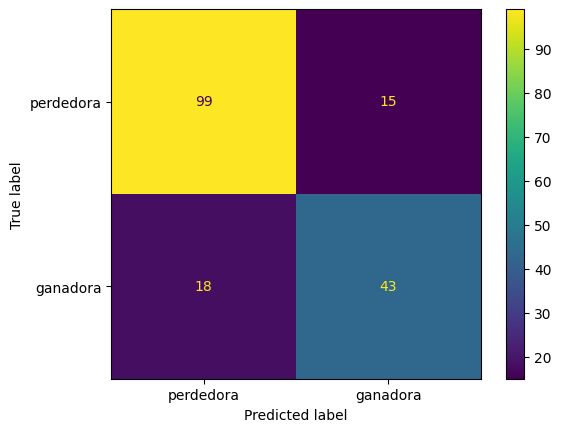

In [ ]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

print("--- MODELO TONTO")
print(classification_report(y_te, p, zero_division=0))

print("--- TU MODELO")
print(classification_report(y_te, pred, zero_division=0))

ConfusionMatrixDisplay.from_estimator(
    modelo, X_te, y_te, display_labels=["perdedora", "ganadora"]);

> **Responde aquí:** compara la exactitud y el F1 de los dos modelos.
> ¿Qué hace mal el modelo tonto que mirar únicamente la exactitud podría
> ocultar?

El modelo tonto obtuvo una exactitud de 0.651 y un F1 de 0.000 para la clase ganadora. La regresión logística mejoró estos resultados, con una exactitud de 0.811 y un F1 de 0.723. El modelo tonto predice siempre “no ganadora”, por lo que su exactitud oculta que no detecta ninguna temporada ganadora. La regresión logística sí detecta aproximadamente el 70 % de ellas, aunque todavía comete errores.

---
## 6 · Sacarlo de tu computadora

Hasta aquí solo había que ejecutar. **Esta parte sí la levantas tú.**

Guardamos el **Pipeline completo** (escalador + modelo). Si guardaras solo la
regresión logística, la API recibiría datos sin escalar y devolvería
disparates **sin lanzar ningún error**.

In [ ]:
import joblib, pathlib

pathlib.Path("modelos").mkdir(exist_ok=True)
joblib.dump(modelo, "modelos/modelo.joblib")     # el Pipeline ENTERO
print("modelos/modelo.joblib guardado")

modelos/modelo.joblib guardado


Estos dos archivos los necesita Docker:

In [ ]:
servir = [
    "import joblib",
    "from fastapi import FastAPI",
    "",
    'modelo = joblib.load("modelos/modelo.joblib")',
    'app = FastAPI(title="Temporada ganadora")',
    "",
    '@app.get("/predecir")',
    "def predecir(gf: int, ga: int):",
    "    x = [[gf, ga, gf - ga]]",
    '    return {"ganadora": bool(modelo.predict(x)[0]),',
    '            "probabilidad": round(float(modelo.predict_proba(x)[0][1]), 3)}',
]

imagen = [
    "FROM python:3.12-slim",
    "WORKDIR /app",
    #"RUN pip install --no-cache-dir fastapi uvicorn scikit-learn joblib",
    "RUN pip install --no-cache-dir fastapi uvicorn scikit-learn==1.6.1 joblib"
    "COPY servir.py .",
    'CMD ["uvicorn", "servir:app", "--host", "0.0.0.0", "--port", "8000"]',
]

open("servir.py", "w", encoding="utf-8").write("\n".join(servir))
open("Dockerfile", "w", encoding="utf-8").write("\n".join(imagen))
print("servir.py y Dockerfile escritos")

servir.py y Dockerfile escritos


In [ ]:
import zipfile
from google.colab import files

with zipfile.ZipFile("nhl_api.zip", "w", zipfile.ZIP_DEFLATED) as archivo:
    archivo.write("Dockerfile")
    archivo.write("servir.py")
    archivo.write("modelos/modelo.joblib")

files.download("nhl_api.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

En la **terminal**, dentro de esta carpeta:

```bash
docker build -t nhl-api .
docker run -p 8000:8000 -v "${PWD}/modelos:/app/modelos" nhl-api
```

Abre **http://localhost:8000/docs**, prueba `/predecir` con `gf=300` y
`ga=250`, y captura la respuesta.

- `-p 8000:8000` conecta el puerto del contenedor con el de tu máquina
- `-v ...` mete tu carpeta `modelos/` dentro del contenedor

> **Prueba esto:** corre el contenedor **sin** el `-v`. ¿Qué pasa y por qué?

---
## Entrega

En una celda de texto al final del notebook:

1. La exactitud y el F1 del **modelo tonto** y de **tu modelo**.
2. Qué hace mal el modelo tonto que la exactitud no deja ver.
3. Por qué se guarda el **Pipeline completo** (`StandardScaler` +
   `LogisticRegression`) y no solo la regresión logística.
4. Qué pasó al correr el contenedor **sin** `-v`.

Y la **captura de la API respondiendo** en `http://localhost:8000/docs`.

---

> **Si haces la parte 7 (opcional)**, añade además:
>
> - la **URL pública** de tu API
> - una captura de `https://<tu-dominio>/docs` con una llamada a `/predecir`
>   que haya respondido bien

1.-La exactitud y el F1 del modelo tonto y de tu modelo.
El modelo tonto aunque logra una exactitud del 65.1% solo siempre predice “no ganadora” con el F1 de cero notamos que no identifica ninguna temporada ganadora.

2.Qué hace mal el modelo tonto que la exactitud no deja ver.
Lo que hace mas es que no es capaz de identificar ninguna temporada ganadora, para true el F1 de la clase gaadora es cero.

Por qué se guarda el Pipeline completo (StandardScaler + LogisticRegression) y no solo la regresión logística.

El pipeline, el escalador,  calcula la media y la desviación estándar de cada característica usando solamente X_tr, y La regresión logística aprende usando esas características escaladas y las respuestas correctas de y_tr.  Si no guardamso el escalador, solo la regresion, se correge el riesgo de recibir valores sin esalar cuando estemos con data de prueba y por ende alterar las predicciones.

Qué pasó al correr el contenedor sin -v.
Se obtuvo error FileNotFoundError: [Errno 2] No such file or directory: 'modelos/modelo.joblib'. El archivo no estaba incluido en la imagen y, sin -v, tampoco estaba disponible mediante el montaje de la carpeta loca


Y la captura de la API respondiendo en http://localhost:8000/docs.
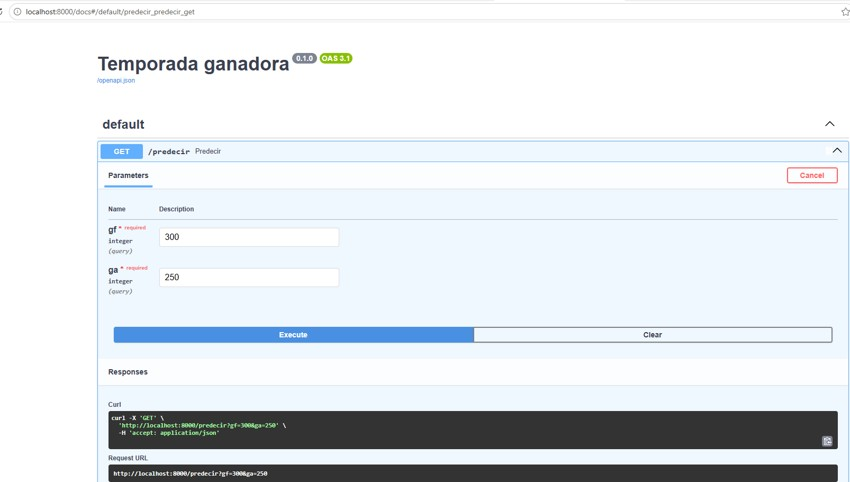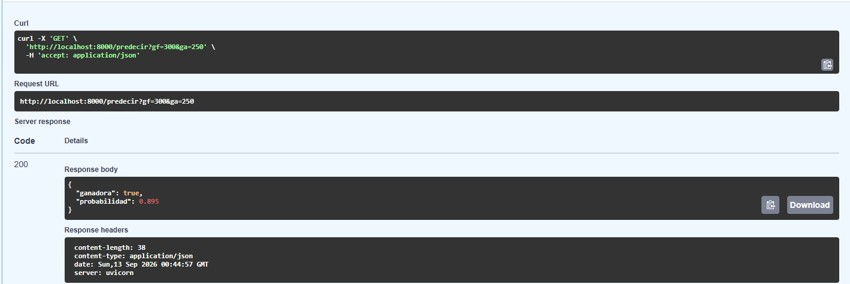


Salida de la parte opcional.

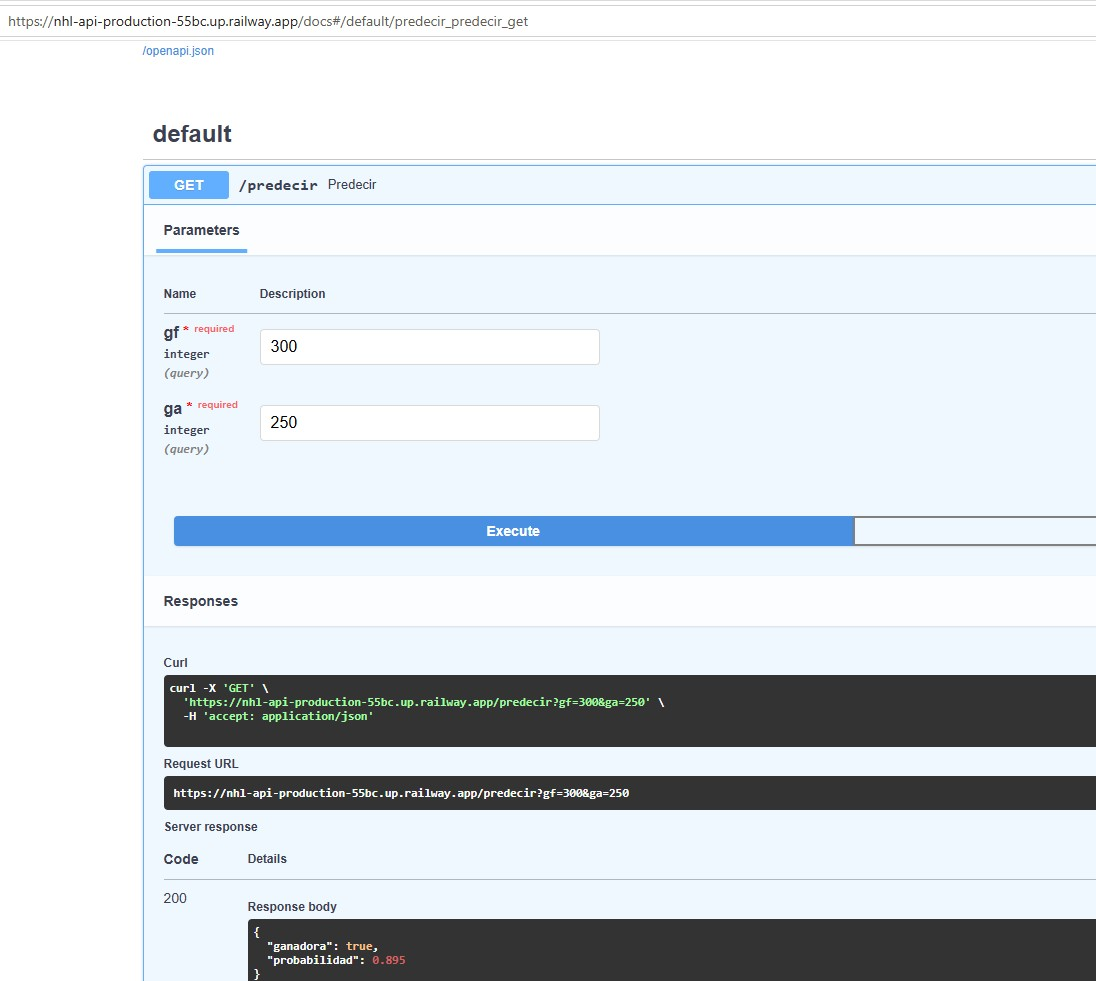

---
# 7 · Del localhost a Internet  ·  OPCIONAL

> **Esta parte no es obligatoria.** El laboratorio ya está completo con la
> entrega de arriba. Lo que sigue es para quien quiera dar el último paso:
> que la API deje de vivir en tu computadora y quede publicada en Internet,
> con una dirección que pueda abrir cualquiera.
>
> Necesitas una cuenta de GitHub y unos 25 minutos.

Tu API funciona… **solo en tu computadora**. Eso es lo que significa
`localhost`: «esta misma máquina». Si cierras la laptop, se acabó; y nadie
más puede abrirla.

```
ANTES

Navegador (el tuyo)
     ↓
localhost:8000
     ↓
Contenedor Docker
     ↓
FastAPI
     ↓
modelo.joblib
```

```
AHORA

Navegador de cualquier persona
          ↓
       Internet
          ↓
  servidor en la nube
          ↓
   Contenedor Docker
          ↓
       FastAPI
          ↓
    modelo.joblib
```

Vamos a subir **el mismo contenedor** a un servidor en la nube y obtener una
URL pública. Usaremos **Railway**, porque construye la aplicación a partir del
`Dockerfile` que ya tienes: no hay que aprender nada nuevo.

```
Proyecto local  →  GitHub  →  Railway  →  Dockerfile  →  contenedor  →  URL pública
```

### Primero: que el modelo viaje dentro de la imagen

En local, el modelo entraba al contenedor **desde tu carpeta**, con `-v`:

```
TU COMPUTADORA              CONTENEDOR
modelos/                    /app/modelos/
└── modelo.joblib    -v →   └── modelo.joblib
```

Pero en la nube **no existe tu carpeta**. El servidor no tiene un `modelos/`
que montar. Así que cambiamos la estrategia: metemos el modelo **dentro de la
imagen** al construirla.

```
modelo.joblib  →  docker build  →  queda dentro de la imagen
```

Eso no significa que el `-v` estuviera mal. Son **dos formas distintas** de
hacer que un archivo esté disponible dentro de un contenedor: montarlo desde
fuera, o copiarlo adentro.

In [ ]:
imagen_nube = [
    "FROM python:3.12-slim",
    "WORKDIR /app",
    "RUN pip install --no-cache-dir fastapi uvicorn scikit-learn joblib",
    "COPY servir.py .",
    "COPY modelos ./modelos",                      # ← el modelo entra a la imagen
    'CMD ["sh", "-c", "uvicorn servir:app --host 0.0.0.0 --port ${PORT:-8000}"]',
]

open("Dockerfile", "w", encoding="utf-8").write("\n".join(imagen_nube))
print("Dockerfile actualizado para la nube")
print()
print(open("Dockerfile", encoding="utf-8").read())

Dockerfile actualizado para la nube

FROM python:3.12-slim
WORKDIR /app
RUN pip install --no-cache-dir fastapi uvicorn scikit-learn joblib
COPY servir.py .
COPY modelos ./modelos
CMD ["sh", "-c", "uvicorn servir:app --host 0.0.0.0 --port ${PORT:-8000}"]


Dos líneas nuevas:

**`COPY modelos ./modelos`** — copia tu carpeta `modelos/` (con el
`.joblib` dentro) a la imagen. Ya no hace falta `-v`.

**`--port ${PORT:-8000}`** — así se lee:

```
¿existe una variable PORT?
   sí  →  usa ese puerto
   no  →  usa 8000
```

En tu computadora `PORT` no está definido, así que sigue siendo el 8000 de
siempre. En la nube, **la plataforma decide el puerto** y te lo pasa en esa
variable. Con esto el mismo Dockerfile sirve en los dos sitios.

### Subir el proyecto a GitHub

Railway lee tu código desde GitHub. En el repositorio tienen que estar, como
mínimo, estos tres:

```
Dockerfile
servir.py
modelos/modelo.joblib
```

Desde la terminal, en la carpeta del proyecto:

```bash
git add .
git commit -m "Deploy NHL API"
git push
```

Si aún no tienes repositorio, créalo en GitHub y sigue las instrucciones que
la propia página te muestra al crearlo.

> **Ojo:** si tienes un `.gitignore` que ignora `*.joblib` o la carpeta
> `modelos/`, el modelo **no se sube** y el despliegue falla. Comprueba con
> `git status` que el `.joblib` aparece entre los archivos añadidos.

### Desplegar en Railway

El flujo, sin depender de cómo se llamen los botones hoy:

1. Entra a **Railway** y crea una cuenta (puedes usar la de GitHub).
2. Crea un **proyecto nuevo**.
3. Elige desplegar **desde un repositorio de GitHub**.
4. Selecciona el repositorio de este laboratorio.
5. Railway detecta el `Dockerfile` y **construye la imagen**. Tarda unos
   minutos: está haciendo lo mismo que hizo tu `docker build`, pero en su
   servidor.
6. Cuando termina, **arranca el contenedor**.
7. En la configuración del servicio, **genera un dominio público**.
8. Abre esa URL.

Tu dirección será algo parecido a esto (**es solo un ejemplo, no la copies**):

```
https://mi-nhl-api.up.railway.app/docs
```

Ahí tienes la misma página `/docs` que viste en `localhost`, pero servida
desde Internet. Prueba `GET /predecir` con `gf = 300` y `ga = 250`. Debería
responder algo con esta forma:

```json
{
  "ganadora": true,
  "probabilidad": 0.87
}
```

El número exacto depende de tu modelo; lo que importa es que responda.

### Qué acabas de conseguir

```
ANTES                        AHORA

Usuario (tú)                 Usuario en Internet
   ↓                                ↓
localhost                       URL pública
   ↓                                ↓
FastAPI                          Railway
   ↓                                ↓
modelo                          contenedor
                                    ↓
                                 FastAPI
                                    ↓
                            Pipeline entrenado
```

Tu modelo dejó de ser un archivo en tu carpeta y se convirtió en un
**servicio al que se puede llamar por HTTP**. Cualquier programa —una app, una
página web, otro script— puede usarlo ahora sin saber nada de scikit-learn.

| Etapa | Dirección | Quién puede acceder |
|---|---|---|
| Notebook | tu archivo | solo tú |
| FastAPI local | `localhost:8000` | tu computadora |
| Docker local | `localhost:8000` | tu computadora |
| Railway | URL HTTPS pública | cualquiera con Internet |

Esa última fila es la diferencia entre **ejecutar** y **desplegar**.